In [299]:
import numpy as np
import matplotlib.pyplot as plt
import pyroomacoustics as pra
import torchaudio
import torchaudio.transforms
import random
import os
import tqdm

In [300]:
def random_room_dimensions():
    length = random.uniform(4, 16)
    width = random.uniform(4, 16)
    height = random.uniform(3, 8)
    return np.array([length, width, height])

def random_head_position(room_dim):
    room_center = 0.5*room_dim
    length = room_center[0] + random.uniform(-0.5, 0.5)
    width = room_center[1] + random.uniform(-0.5, 0.5)
    height = random.uniform(1, 2)
    return np.array([length, width, height])

def define_ears_position(head_position):
    ear_center_l = np.array([head_position[0], head_position[1] - 0.08, head_position[2]])
    ear_center_r = np.array([head_position[0], head_position[1] + 0.08, head_position[2]])
    return np.array([ear_center_l, ear_center_r])

def define_mics_position(ears_position):
    ear_center_l, ear_center_r = ears_position
    mic_l_1 = np.array([ear_center_l[0], ear_center_l[1], ear_center_l[2] - 0.01])
    mic_l_2 = np.array([ear_center_l[0], ear_center_l[1], ear_center_l[2] + 0.01])
    mic_r_1 = np.array([ear_center_r[0], ear_center_r[1], ear_center_r[2] - 0.01])
    mic_r_2 = np.array([ear_center_r[0], ear_center_r[1], ear_center_r[2] + 0.01])
    return np.array([mic_l_1, mic_l_2, mic_r_1, mic_r_2])

def random_mouth_position(head_position):
    length = head_position[0] + random.uniform(0.10, 0.16)
    width = head_position[1]
    height = head_position[2] - random.uniform(0.03, 0.05)
    return np.array([length, width, height])

def random_distractor_position(room_dim):
    # distance = random.uniform(1, 4)
    # angle = random.uniform(0, 2 * np.pi)
    # length = room_center[0] + distance*np.cos(angle)
    # width = room_center[1] + distance*np.sin(angle)
    room_center = 0.5*room_dim
    rcx, rcy = room_center[0], room_center[1]
    x, y = random.uniform(1, 0.75*rcx), random.uniform(1, 0.75*rcy)
    length = rcx + x if random.randint(0, 1) else rcx - x
    width = rcy + y if random.randint(0, 1) else rcy - y
    height = random.uniform(1, 2)
    return np.array([length, width, height])

In [301]:
room_dim = random_room_dimensions()
print(room_dim)

[8.2110607  4.68004008 3.38046923]


In [302]:
room_center = room_dim / 2
print(room_center)

[4.10553035 2.34002004 1.69023462]


In [303]:
head_position = random_head_position(room_dim)
print(head_position)

[4.01685615 2.64223754 1.52785961]


In [304]:
ears_position = define_ears_position(head_position)
print(ears_position)

[[4.01685615 2.56223754 1.52785961]
 [4.01685615 2.72223754 1.52785961]]


In [305]:
mics_position = define_mics_position(ears_position)
print(mics_position)

[[4.01685615 2.56223754 1.51785961]
 [4.01685615 2.56223754 1.53785961]
 [4.01685615 2.72223754 1.51785961]
 [4.01685615 2.72223754 1.53785961]]


In [306]:
mouth_position = random_mouth_position(head_position)
print(mouth_position)

[4.16022339 2.64223754 1.48457483]


In [307]:
room_center

array([4.10553035, 2.34002004, 1.69023462])

In [308]:
distractor_position = random_distractor_position(room_dim)
print(distractor_position)

[6.72971178 3.7310317  1.65281032]


In [309]:
def random_snr():
    return random.uniform(-5, 5)

def random_rt60():
    return random.uniform(0, 1)

In [310]:
room = pra.ShoeBox(room_dim, fs=16000)

In [311]:
rt60 = random_rt60()
e_absorption, max_order = pra.inverse_sabine(rt60, room_dim)

In [312]:
room.add_source(mouth_position)

In [313]:
room.add_microphone_array(mics_position.T)

In [314]:
room.add_source(distractor_position)

(<Figure size 640x480 with 1 Axes>, <Axes3D: >)

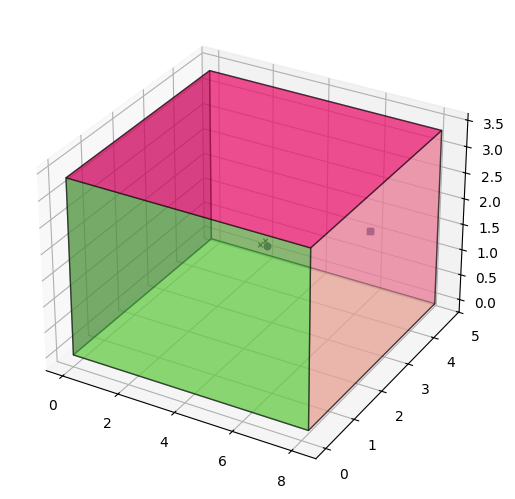

In [315]:
room.plot()